In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.dropna(inplace = True)

In [4]:
df.shape

(714, 3)

In [5]:
df.sample(5)

,Survived,Age,Fare
492,0,55.0,30.500
12,0,20.0,8.050
317,0,54.0,14.000
885,0,39.0,29.125
636,0,32.0,7.925


In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0] 

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 0)

In [8]:
X_train.head(2)

,Age,Fare
387,36.0,13.0000
685,25.0,41.5792


In [9]:
clf = DecisionTreeClassifier()

In [10]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_train)
accuracy_score(y_train,y_pred)

0.9737302977232924

In [11]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,scoring='accuracy'))

np.float64(0.6204570077809514)

In [12]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [13]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [14]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [15]:
trf.named_transformers_['first'].n_bins_

array([10])

In [16]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.7417,   7.8958,   8.6625,  12.35  ,  15.5   ,
               25.9292,  27.9   ,  39.6875,  78.2667, 512.3292])         ],
      dtype=object)

In [17]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [18]:
output['age_labels'] = pd.cut(x=X_train['Age'],bins = trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] =  pd.cut(x=X_train['Fare'],bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

# ahiya bin_edges[0] bcz bin_edges ma it is np of arr of arrays as multiple cols can be passed in K_bins_Descritizers

In [19]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
309,30.0,5.0,56.9292,8.0,"(28.0, 31.0]","(39.688, 78.267]"
108,38.0,7.0,7.8958,2.0,"(35.0, 42.0]","(7.742, 7.896]"
722,34.0,6.0,13.0000,4.0,"(31.0, 35.0]","(12.35, 15.5]"
407,3.0,0.0,18.7500,5.0,"(0.67, 14.0]","(15.5, 25.929]"
404,20.0,2.0,8.6625,3.0,"(18.0, 22.0]","(7.896, 8.662]"


In [20]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [21]:
accuracy_score(y_test,y_pred2)

0.6993006993006993

In [22]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6330985915492957)

In [25]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    
    trf = ColumnTransformer([
        ('first', kbin_age, ['Age']),
        ('second', kbin_fare, ['Fare'])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y, cv=10, scoring='accuracy')))
    
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14,4))
    sns.histplot(X['Age'], ax=ax1)
    sns.histplot(X_trf[:,0], ax=ax2)
    ax1.set_title('Before')
    ax2.set_title('After')

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14,4))
    sns.histplot(X['Fare'], ax=ax1)
    sns.histplot(X_trf[:,1], ax=ax2)
    ax1.set_title('Before')
    ax2.set_title('After')
    
    plt.show()

0.6584702660406886


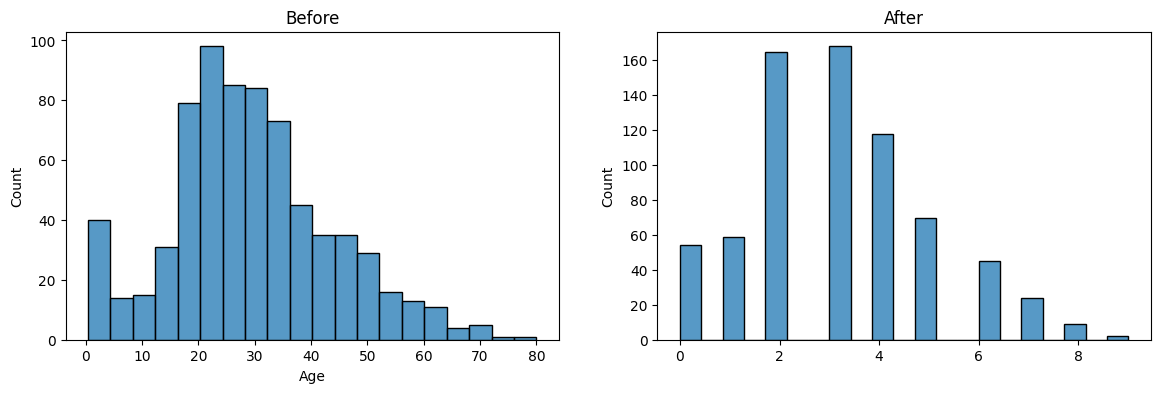

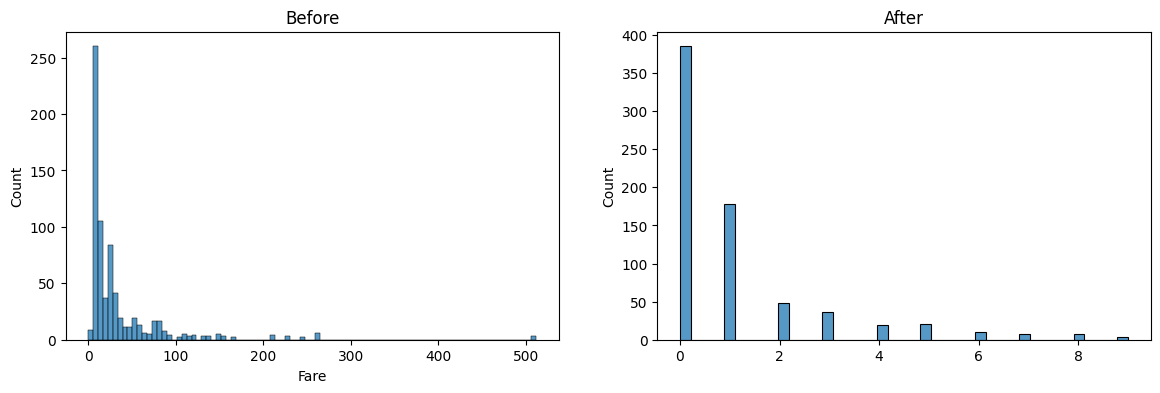

In [27]:
discretize(10,'kmeans')

C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\MAANSHA\anaconda3\envs\ml-gpu\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.682140062597809


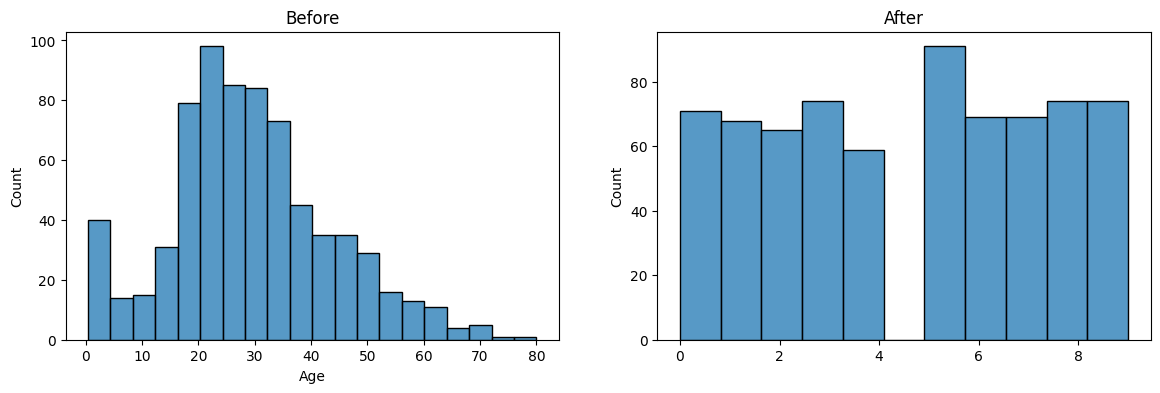

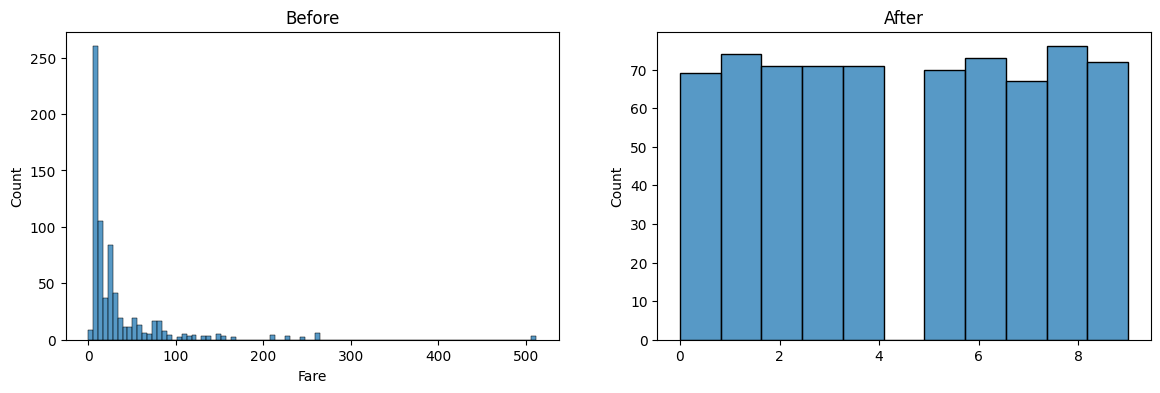

In [28]:
discretize(10,'quantile')

0.6864632237871675


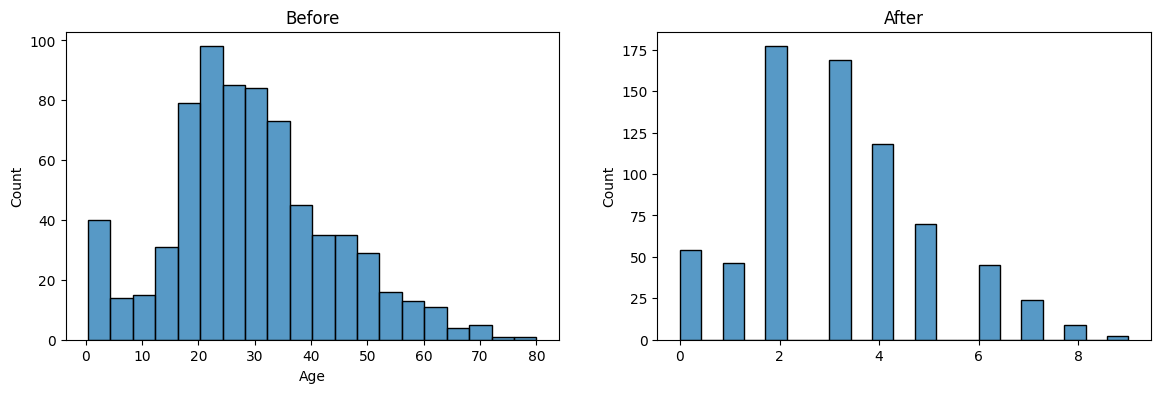

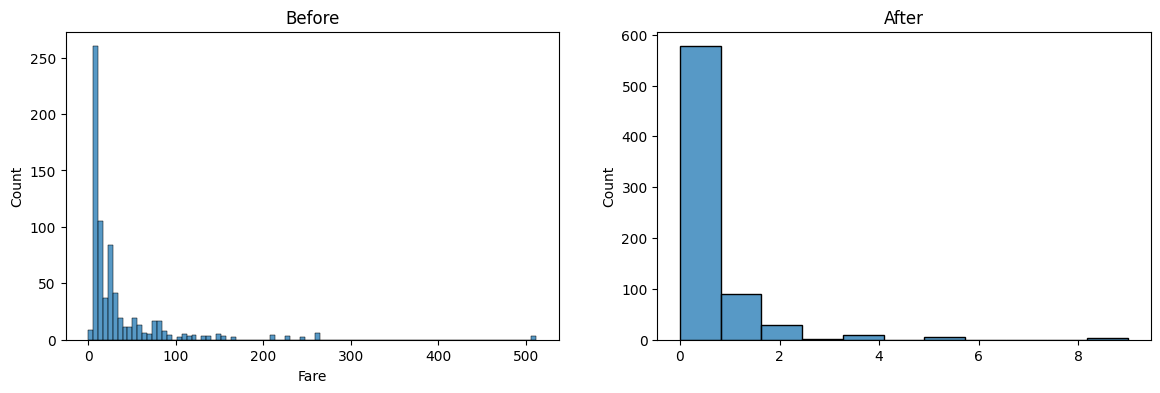

In [29]:
discretize(10,'uniform')